In [1]:
import PythonicDISORT
from PythonicDISORT.subroutines import _compare
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from math import pi

Previously saved reference solutions will be loaded if F2PY-wrapped Stamnes' DISORT is unavailable.

In [2]:
disort_is_installed = True
try:
    import disort
    print("Stamnes' DISORT imported.")
except ImportError:
    disort_is_installed = False
    print("Stamnes' DISORT unavailable. Cached results will be used.")

Stamnes' DISORT unavailable. Cached results will be used.


# Table of Contents
* [Test Problem 8:  Absorbing / Isotropic-Scattering Medium With Two Computational Layers](#Test-Problem-8:--Absorbing-/-Isotropic-Scattering-Medium-With-Two-Computational-Layers)
* [8a and setup](#8a-and-setup)
* [8b](#8b)
* [8c](#8c)
* [8ARTS_A](#8ARTS_A)
* [8ARTS_B](#8ARTS_B)


# Test Problem 8:  Absorbing / Isotropic-Scattering Medium With Two Computational Layers

In this test problem we return to the isotropic phase function, however, there are now two atmospheric layers with different optical properties. Realistic atmospheres are vertically and horizontally inhomogeneous. PythonicDISORT, and DISORT, cannot model horizontal inhomogeneity as they fundamentally assume a plane-parallel atmosphere. Vertical inhomogeneity on the other hand can be modeled by discretizing the atmosphere into layers. Naturally, if consecutive atmospheric layers have identical optical properties then they can be merged and test problem 11 checks for this consistency. The source has been changed from a direct beam (modeling sunlight) to isotropic illumination at the top-boundary (modeling radiation which has been emitted or scattered by a higher atmospheric object).

Flux results for 8a, 8b and 8c can be compared to Table 1 of Ozisik, M. and S. Shouman, 1980: *Source Function Expansion Method for Radiative Transfer in a Two-Layer Slab*, J.Q.S.R.T. 24, 441-449. The intensity field of the upwelling radiation, which can be compared to satellite measurements, is plotted for each subproblem.

# 8a and setup

**PythonicDISORT**

In [3]:
######################################### PYDISORT ARGUMENTS #######################################

tau_arr = np.array([0.25, 0.5])  # Two layers; total thickness is 0.5
omega_arr = np.array([0.5, 0.3])  # Single-scattering albedo for each layer
NQuad = 8  # 8 streams (4 quadrature nodes for each hemisphere)
Leg_coeffs_all = np.zeros((2, 9))
Leg_coeffs_all[:, 0] = 1  # The phase functions for both layers are isotropic
mu0 = 0
I0 = 0  # No direct beam
phi0 = 0

# Optional (used)
b_neg = 1 / pi  # Intensity of top-boundary isotropic illumination

# Optional (unused)
NLeg = None
NFourier = None
b_pos = 0
only_flux = False
f_arr = 0
NT_cor = False
BDRF_Fourier_modes=[]
s_poly_coeffs = np.array([[]])
use_banded_solver_NLayers=10
autograd_compatible=False

####################################################################################################

In [4]:
# Call pydisort function
mu_arr, flux_up, flux_down, u0, u = PythonicDISORT.pydisort(
    tau_arr, omega_arr,
    NQuad,
    Leg_coeffs_all,
    mu0, I0, phi0,
    b_neg=b_neg,
)

**Setup for tests**

In [5]:
# Reorder mu_arr from smallest to largest
reorder_mu = np.argsort(mu_arr)
mu_arr_RO = mu_arr[reorder_mu]

# We may not want to compare intensities around the direct beam
deg_around_beam_to_not_compare = 0
mu_to_compare = (
    np.abs(np.arccos(np.abs(mu_arr_RO)) - np.arccos(mu0)) * 180 / pi
    > deg_around_beam_to_not_compare
)
mu_test_arr_RO = mu_arr_RO[mu_to_compare]

In [6]:
# Number of phi grid points
Nphi = 2
phi_arr = np.random.random(Nphi) * 2 * pi

# tau test points
tau_test_arr = np.array([0, 0.25, 0.5])
Ntau = len(tau_test_arr)

**Stamnes' DISORT**

In [7]:
# Stamnes' DISORT arguments
nlyr = 2
nmom = NQuad
nstr = NQuad
numu = NQuad
nphi = Nphi
ntau = Ntau
usrang = True
usrtau = True
ibcnd = 0
onlyfl = False
prnt = np.array([False, False, False, False, False])  # Prints to CMD instead of this notebook
plank = False
lamber = True
deltamplus = False
do_pseudo_sphere = False
dtauc = np.concatenate([[tau_arr[0]], np.diff(tau_arr)])
ssalb = omega_arr
pmom = Leg_coeffs_all.T
temper = np.zeros(nlyr + 1)
wvnmlo = 0
wvnmhi = 0
utau = tau_test_arr
umu0 = mu0
phi0 = phi0
umu = mu_arr_RO
phi = phi_arr
fbeam = I0
fisot = b_neg
albedo = 0
btemp = 0
ttemp = 0
temis = 0
earth_radius = 6371
h_lyr = np.zeros(nlyr + 1)
rhoq = np.zeros((nstr // 2, nstr + 1, nstr))
rhou = np.zeros((numu, nstr // 2 + 1, nstr))
rho_accurate = np.zeros((numu, nphi))
bemst = np.zeros(nstr // 2)
emust = np.zeros(numu)
accur = 0
header = ""
rfldir = np.zeros(ntau)
rfldn = np.zeros(ntau)
flup = np.zeros(ntau)
dfdt = np.zeros(ntau)
uavg = np.zeros(ntau)
uu = np.zeros((numu, ntau, nphi))
albmed = np.zeros(numu)
trnmed = np.zeros(numu)

In [8]:
if disort_is_installed:
    # Run disort, putting DFDT, UAVG, and UU in a, b, and c, respectively
    rfldir, rfldn, flup, dfdt, uavg, uu, albmed, trnmed = disort.disort(usrang, usrtau, ibcnd, onlyfl, prnt, plank, lamber, deltamplus, do_pseudo_sphere, dtauc, ssalb,
                            pmom, temper, wvnmlo, wvnmhi, utau, umu0, phi0 * 180/pi, umu, phi * 180/pi, fbeam, fisot, albedo, btemp, ttemp,
                            temis, earth_radius, h_lyr, rhoq, rhou, rho_accurate, bemst, emust, accur, header, rfldir,
                            rfldn, flup, dfdt, uavg, uu, albmed, trnmed)
    results = {
        "uu": uu,
        "flup": flup,
        "rfldn": rfldn,
        "rfldir": rfldir,
        "tau_test_arr": tau_test_arr,
        "phi_arr": phi_arr
    }
else:
    # Load saved results from Stamnes' DISORT
    results = np.load("Stamnes_results/8a_test.npz")

**Comparisons**

In [9]:
(
    diff_flux_up,
    ratio_flux_up,
    diff_flux_down_diffuse,
    ratio_flux_down_diffuse,
    diff_flux_down_direct,
    ratio_flux_down_direct,
    diff,
    diff_ratio,
) = _compare(results, mu_to_compare, reorder_mu, flux_up, flux_down, u)

Max pointwise differences

Upward (diffuse) fluxes
Difference = 1.8563882236977136e-08
Difference ratio = 1.0000000188977

Downward (diffuse) fluxes
Difference = 6.096862936733061e-08
Difference ratio = 1.188167739685346e-07

Direct (downward) fluxes
Difference = 0.0
Difference ratio = 0.0

Intensities

At tau = 0.25
Max pointwise difference = 1.4667068143348061e-08
At tau = 0.0
Max pointwise difference ratio = 2.576816759750074e-07



**Does the test pass?**

In [10]:
assert np.max(ratio_flux_up[diff_flux_up > 1e-3], initial=0) < 1e-3
assert np.max(ratio_flux_down_diffuse[diff_flux_down_diffuse > 1e-3], initial=0) < 1e-3
assert np.max(ratio_flux_down_direct[diff_flux_down_direct > 1e-3], initial=0) < 1e-3
assert np.max(diff_ratio[diff > 1e-3], initial=0) < 1e-2

'''np.savez_compressed (
    "Stamnes_results/8a_test",
    phi_arr=phi_arr,
    tau_test_arr=tau_test_arr,
    uu=uu,
    flup=flup,
    rfldn=rfldn,
    rfldir=rfldir,
)'''

print("The test passes")

The test passes


**Plots**

In [11]:
Nphi_plot = int((NQuad * pi) // 2) * 2 + 1
phi_arr_plot, full_weights_phi = PythonicDISORT.subroutines.Clenshaw_Curtis_quad(Nphi_plot)

MU_ARR, PHI_ARR = np.meshgrid(phi_arr_plot, mu_arr[:NQuad // 2])

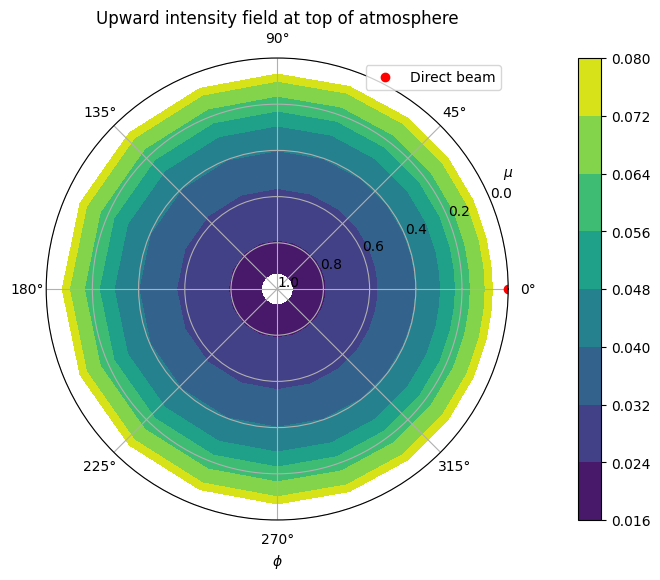

In [12]:
plot = u(0, phi_arr_plot)[:NQuad // 2]

fig, ax = plt.subplots(figsize=(9, 6), subplot_kw={"projection": "polar"})

_cf = ax.contourf(MU_ARR, PHI_ARR, plot)
#ax.plot(phi0, mu0, "o", color="red", label="Direct beam")

ax.set_rlim(1.0, 0.0)

ax.set_xlabel(r"$\phi$")
#ax.set_ylabel(r"$\mu$")
ax.text(1, 0.75, r"$\mu$", transform=ax.transAxes,
        rotation=0, ha="center", va="center")
fig.colorbar(_cf, ax=ax, pad=0.10)
ax.set_title("Upward intensity field at top of atmosphere")
#ax.legend()
plt.show()


----------

# 8b

**PythonicDISORT**

In [13]:
######################################### PYDISORT ARGUMENTS #######################################

tau_arr = np.array([0.25, 0.5])
omega_arr = np.array([0.8, 0.95])
NQuad = 8
Leg_coeffs_all = np.zeros((2, 9))
Leg_coeffs_all[:, 0] = 1
mu0 = 0
I0 = 0
phi0 = 0

# Optional (used)
b_neg = 1 / pi

# Optional (unused)
NLeg = None
NFourier = None
b_pos = 0
only_flux = False
f_arr = 0
NT_cor = False
BDRF_Fourier_modes=[]
s_poly_coeffs = np.array([[]])
use_banded_solver_NLayers=10
autograd_compatible=False

####################################################################################################

In [14]:
# Call pydisort function
mu_arr, flux_up, flux_down, u0, u = PythonicDISORT.pydisort(
    tau_arr, omega_arr,
    NQuad,
    Leg_coeffs_all,
    mu0, I0, phi0,
    b_neg=b_neg,
)

**Stamnes' DISORT**

In [15]:
# tau test points
tau_test_arr = np.array([0, 0.25, 0.5])
Ntau = len(tau_test_arr)

In [16]:
# Stamnes' DISORT arguments
nlyr = 2
nmom = NQuad
nstr = NQuad
numu = NQuad
nphi = Nphi
ntau = Ntau
usrang = True
usrtau = True
ibcnd = 0
onlyfl = False
prnt = np.array([False, False, False, False, False])  # Prints to CMD instead of this notebook
plank = False
lamber = True
deltamplus = False
do_pseudo_sphere = False
dtauc = np.concatenate([[tau_arr[0]], np.diff(tau_arr)])
ssalb = omega_arr
pmom = Leg_coeffs_all.T
temper = np.zeros(nlyr + 1)
wvnmlo = 0
wvnmhi = 0
utau = tau_test_arr
umu0 = mu0
phi0 = phi0
umu = mu_arr_RO
phi = phi_arr
fbeam = I0
fisot = b_neg
albedo = 0
btemp = 0
ttemp = 0
temis = 0
earth_radius = 6371
h_lyr = np.zeros(nlyr + 1)
rhoq = np.zeros((nstr // 2, nstr + 1, nstr))
rhou = np.zeros((numu, nstr // 2 + 1, nstr))
rho_accurate = np.zeros((numu, nphi))
bemst = np.zeros(nstr // 2)
emust = np.zeros(numu)
accur = 0
header = ""
rfldir = np.zeros(ntau)
rfldn = np.zeros(ntau)
flup = np.zeros(ntau)
dfdt = np.zeros(ntau)
uavg = np.zeros(ntau)
uu = np.zeros((numu, ntau, nphi))
albmed = np.zeros(numu)
trnmed = np.zeros(numu)

In [17]:
if disort_is_installed:
    # Run disort, putting DFDT, UAVG, and UU in a, b, and c, respectively
    rfldir, rfldn, flup, dfdt, uavg, uu, albmed, trnmed = disort.disort(usrang, usrtau, ibcnd, onlyfl, prnt, plank, lamber, deltamplus, do_pseudo_sphere, dtauc, ssalb,
                            pmom, temper, wvnmlo, wvnmhi, utau, umu0, phi0 * 180/pi, umu, phi * 180/pi, fbeam, fisot, albedo, btemp, ttemp,
                            temis, earth_radius, h_lyr, rhoq, rhou, rho_accurate, bemst, emust, accur, header, rfldir,
                            rfldn, flup, dfdt, uavg, uu, albmed, trnmed)
    results = {
        "uu": uu,
        "flup": flup,
        "rfldn": rfldn,
        "rfldir": rfldir,
        "tau_test_arr": tau_test_arr,
        "phi_arr": phi_arr
    }
else:
    # Load saved results from Stamnes' DISORT
    results = np.load("Stamnes_results/8b_test.npz")

**Comparisons**

In [18]:
(
    diff_flux_up,
    ratio_flux_up,
    diff_flux_down_diffuse,
    ratio_flux_down_diffuse,
    diff_flux_down_direct,
    ratio_flux_down_direct,
    diff,
    diff_ratio,
) = _compare(results, mu_to_compare, reorder_mu, flux_up, flux_down, u)

Max pointwise differences

Upward (diffuse) fluxes
Difference = 8.567015889417974e-08
Difference ratio = 4.809705795532518e-08

Downward (diffuse) fluxes
Difference = 1.0243884362992617e-07
Difference ratio = 1.5749710107460493e-07

Direct (downward) fluxes
Difference = 0.0
Difference ratio = 0.0

Intensities

At tau = 0.5
Max pointwise difference = 3.871370832242427e-08
At tau = 0.5
Max pointwise difference ratio = 3.8447848209367307e-07



**Does the test pass?**

In [19]:
assert np.max(ratio_flux_up[diff_flux_up > 1e-3], initial=0) < 1e-3
assert np.max(ratio_flux_down_diffuse[diff_flux_down_diffuse > 1e-3], initial=0) < 1e-3
assert np.max(ratio_flux_down_direct[diff_flux_down_direct > 1e-3], initial=0) < 1e-3
assert np.max(diff_ratio[diff > 1e-3], initial=0) < 1e-2

'''np.savez_compressed (
    "Stamnes_results/8b_test",
    phi_arr=phi_arr,
    tau_test_arr=tau_test_arr,
    uu=uu,
    flup=flup,
    rfldn=rfldn,
    rfldir=rfldir,
)'''

print("The test passes")

The test passes


**Plots**

In [20]:
Nphi_plot = int((NQuad * pi) // 2) * 2 + 1
phi_arr_plot, full_weights_phi = PythonicDISORT.subroutines.Clenshaw_Curtis_quad(Nphi_plot)

MU_ARR, PHI_ARR = np.meshgrid(phi_arr_plot, mu_arr[:NQuad // 2])

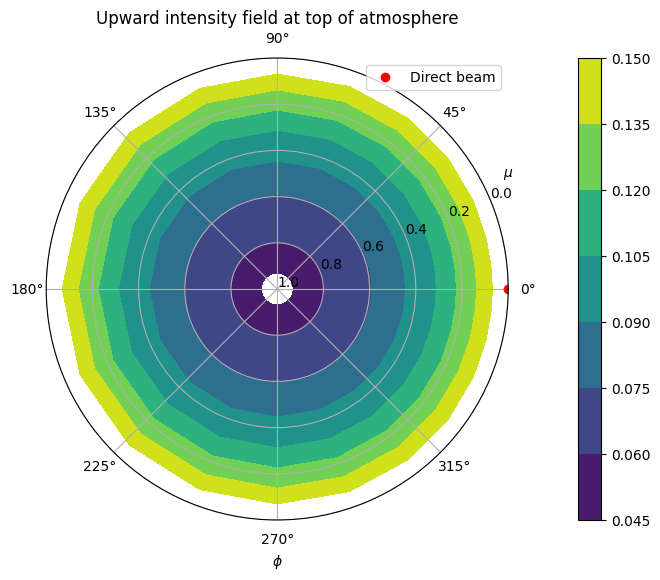

In [21]:
plot = u(0, phi_arr_plot)[:NQuad // 2]

fig, ax = plt.subplots(figsize=(9, 6), subplot_kw={"projection": "polar"})

_cf = ax.contourf(MU_ARR, PHI_ARR, plot)
#ax.plot(phi0, mu0, "o", color="red", label="Direct beam")

ax.set_rlim(1.0, 0.0)

ax.set_xlabel(r"$\phi$")
#ax.set_ylabel(r"$\mu$")
ax.text(1, 0.75, r"$\mu$", transform=ax.transAxes,
        rotation=0, ha="center", va="center")
fig.colorbar(_cf, ax=ax, pad=0.10)
ax.set_title("Upward intensity field at top of atmosphere")
#ax.legend()
plt.show()


-------

# 8c

**PythonicDISORT**

In [22]:
######################################### PYDISORT ARGUMENTS #######################################

tau_arr = np.array([1, 3])
omega_arr = np.array([0.8, 0.95])
NQuad = 8
Leg_coeffs_all = np.zeros((2, 9))
Leg_coeffs_all[:, 0] = 1
mu0 = 0
I0 = 0
phi0 = 0

# Optional (used)
b_neg = 1 / pi

# Optional (unused)
NLeg = None
NFourier = None
b_pos = 0
only_flux = False
f_arr = 0
NT_cor = False
BDRF_Fourier_modes=[]
s_poly_coeffs = np.array([[]])
use_banded_solver_NLayers=10
autograd_compatible=False

####################################################################################################

In [23]:
# Call pydisort function
mu_arr, flux_up, flux_down, u0, u = PythonicDISORT.pydisort(
    tau_arr, omega_arr,
    NQuad,
    Leg_coeffs_all,
    mu0, I0, phi0,
    b_neg=b_neg,
)

**Stamnes' DISORT**

In [24]:
# tau test points
tau_test_arr = np.array([0, 0.25, 0.5])
Ntau = len(tau_test_arr)

In [25]:
# Stamnes' DISORT arguments
nlyr = 2
nmom = NQuad
nstr = NQuad
numu = NQuad
nphi = Nphi
ntau = Ntau
usrang = True
usrtau = True
ibcnd = 0
onlyfl = False
prnt = np.array([False, False, False, False, False])  # Prints to CMD instead of this notebook
plank = False
lamber = True
deltamplus = False
do_pseudo_sphere = False
dtauc = np.concatenate([[tau_arr[0]], np.diff(tau_arr)])
ssalb = omega_arr
pmom = Leg_coeffs_all.T
temper = np.zeros(nlyr + 1)
wvnmlo = 0
wvnmhi = 0
utau = tau_test_arr
umu0 = mu0
phi0 = phi0
umu = mu_arr_RO
phi = phi_arr
fbeam = I0
fisot = b_neg
albedo = 0
btemp = 0
ttemp = 0
temis = 0
earth_radius = 6371
h_lyr = np.zeros(nlyr + 1)
rhoq = np.zeros((nstr // 2, nstr + 1, nstr))
rhou = np.zeros((numu, nstr // 2 + 1, nstr))
rho_accurate = np.zeros((numu, nphi))
bemst = np.zeros(nstr // 2)
emust = np.zeros(numu)
accur = 0
header = ""
rfldir = np.zeros(ntau)
rfldn = np.zeros(ntau)
flup = np.zeros(ntau)
dfdt = np.zeros(ntau)
uavg = np.zeros(ntau)
uu = np.zeros((numu, ntau, nphi))
albmed = np.zeros(numu)
trnmed = np.zeros(numu)

In [26]:
if disort_is_installed:
    # Run disort, putting DFDT, UAVG, and UU in a, b, and c, respectively
    rfldir, rfldn, flup, dfdt, uavg, uu, albmed, trnmed = disort.disort(usrang, usrtau, ibcnd, onlyfl, prnt, plank, lamber, deltamplus, do_pseudo_sphere, dtauc, ssalb,
                            pmom, temper, wvnmlo, wvnmhi, utau, umu0, phi0 * 180/pi, umu, phi * 180/pi, fbeam, fisot, albedo, btemp, ttemp,
                            temis, earth_radius, h_lyr, rhoq, rhou, rho_accurate, bemst, emust, accur, header, rfldir,
                            rfldn, flup, dfdt, uavg, uu, albmed, trnmed)
    results = {
        "uu": uu,
        "flup": flup,
        "rfldn": rfldn,
        "rfldir": rfldir,
        "tau_test_arr": tau_test_arr,
        "phi_arr": phi_arr
    }
else:
    # Load saved results from Stamnes' DISORT
    results = np.load("Stamnes_results/8c_test.npz")

**Comparisons**

In [27]:
(
    diff_flux_up,
    ratio_flux_up,
    diff_flux_down_diffuse,
    ratio_flux_down_diffuse,
    diff_flux_down_direct,
    ratio_flux_down_direct,
    diff,
    diff_ratio,
) = _compare(results, mu_to_compare, reorder_mu, flux_up, flux_down, u)

Max pointwise differences

Upward (diffuse) fluxes
Difference = 3.9356411074553677e-08
Difference ratio = 1.3939494835425568e-07

Downward (diffuse) fluxes
Difference = 1.1920928977282585e-07
Difference ratio = 1.1920927556197281e-07

Direct (downward) fluxes
Difference = 0.0
Difference ratio = 0.0

Intensities

At tau = 0.5
Max pointwise difference = 2.394231335411945e-08
At tau = 0.5
Max pointwise difference ratio = 1.3725599440894965e-07



**Does the test pass?**

In [28]:
assert np.max(ratio_flux_up[diff_flux_up > 1e-3], initial=0) < 1e-3
assert np.max(ratio_flux_down_diffuse[diff_flux_down_diffuse > 1e-3], initial=0) < 1e-3
assert np.max(ratio_flux_down_direct[diff_flux_down_direct > 1e-3], initial=0) < 1e-3
assert np.max(diff_ratio[diff > 1e-3], initial=0) < 1e-2

'''np.savez_compressed (
    "Stamnes_results/8c_test",
    phi_arr=phi_arr,
    tau_test_arr=tau_test_arr,
    uu=uu,
    flup=flup,
    rfldn=rfldn,
    rfldir=rfldir,
)'''

print("The test passes")

The test passes


**Plots**

In [29]:
Nphi_plot = int((NQuad * pi) // 2) * 2 + 1
phi_arr_plot, full_weights_phi = PythonicDISORT.subroutines.Clenshaw_Curtis_quad(Nphi_plot)

MU_ARR, PHI_ARR = np.meshgrid(phi_arr_plot, mu_arr[:NQuad // 2])

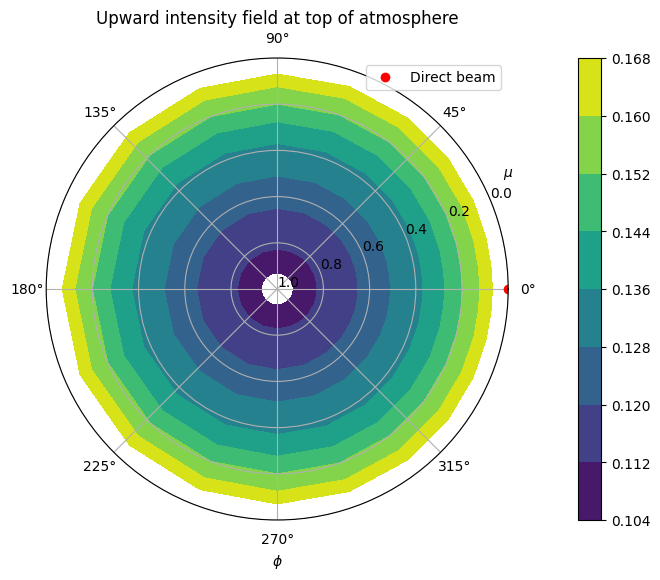

In [30]:
plot = u(0, phi_arr_plot)[:NQuad // 2]

fig, ax = plt.subplots(figsize=(9, 6), subplot_kw={"projection": "polar"})

_cf = ax.contourf(MU_ARR, PHI_ARR, plot)
#ax.plot(phi0, mu0, "o", color="red", label="Direct beam")

ax.set_rlim(1.0, 0.0)

ax.set_xlabel(r"$\phi$")
#ax.set_ylabel(r"$\mu$")
ax.text(1, 0.75, r"$\mu$", transform=ax.transAxes,
        rotation=0, ha="center", va="center")
fig.colorbar(_cf, ax=ax, pad=0.10)
ax.set_title("Upward intensity field at top of atmosphere")
#ax.legend()
plt.show()


-------

# 8ARTS_A

Test 8ARTS_A is a unique test wherein the source is internal blackbody emission, which is isotropic, and the intensity results are compared to ARTS [[1](#cite-ARTS), [2](#cite-ARTSwebsite)] instead of DISORT (thank you Richard Larsson for the data and test idea).

**PythonicDISORT**

In [31]:
from ARTS_data.inpydis import src, tau

nv = len(src)
pyth = np.empty((nv, 20, 8))

for i in range(nv):
    mu_arr, flux_up, flux_down, u0, u = PythonicDISORT.pydisort(
        tau_arr=tau[i],
        omega_arr=tau[i] * 0,
        NQuad=8,
        Leg_coeffs_all=np.ones((len(tau[i]), 1)),
        I0=0.0, 
        mu0=0.0, 
        phi0=0.0,
        NLeg=1,
        NFourier=1,
        s_poly_coeffs=src[i] * 1e15,
    )

    pyth[i] = u(tau[i], 0.0).T

    
# Unused optional arguments
NLeg = None
NFourier = None
b_pos = 0
b_neg = 0
only_flux = False
f_arr = 0
NT_cor = False
BDRF_Fourier_modes = []
use_banded_solver_NLayers = 10
autograd_compatible = False

In [32]:
ARTS_results = np.load("Stamnes_results/8ARTS_A_test.npy")
assert np.max(np.abs(pyth[:, -1, -1] - ARTS_results) / ARTS_results) < 1e-2

print("The test passes")

The test passes


Text(0.5, 0, 'Dirac frequency [index count]')

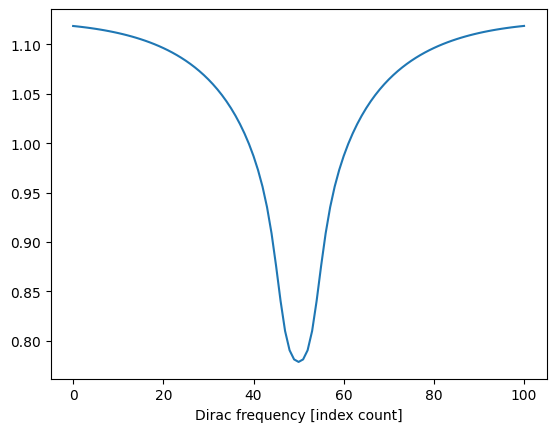

In [33]:
plt.plot(pyth[:, -1, -1])
plt.xlabel("Dirac frequency [index count]")

# 8ARTS_B

Input data for test 8ARTS_B was supplied by our ARTS collaborators and results are compared against Stamnes' DISORT.

In [34]:
from ARTS_data.pydisort_data import (
    optical_thicknesses,
    single_scattering_albedo,
    quadrature_dimension,
    legendre_coefficients,
    TEMPER,
)
from scipy.constants import speed_of_light

freqs = [31.5e9, 165e9, 666e9]
WVNM = np.array(freqs) / (100.0 * speed_of_light)
WVNMHI = np.ones(len(freqs)) * 50000
WVNMLO = np.zeros(len(freqs))

In [35]:
for ifreq in range(len(freqs)):
    
    ######################################### PYDISORT ##############################################

    tau_arr = optical_thicknesses[ifreq]
    omega_arr = single_scattering_albedo[ifreq]
    NQuad = quadrature_dimension
    # Stamnes' DISORT needs an extra coefficient but by our settings it will not be used
    Leg_coeffs_all = np.hstack((legendre_coefficients[ifreq], np.zeros((len(tau_arr), 1))))
    mu0 = 0
    I0 = 0  # No direct beam
    phi0 = 0

    # Optional (used)
    s_poly_coeffs = PythonicDISORT.subroutines.generate_s_poly_coeffs(
        tau_arr, TEMPER, WVNMLO[ifreq], WVNMHI[ifreq],
    )
    b_pos = PythonicDISORT.subroutines.blackbody_contrib_to_BCs(
        np.mean(TEMPER), WVNMLO[ifreq], WVNMHI[ifreq]
    ) # Using an arbitrary temperature since surface temperature data is missing
    b_neg = PythonicDISORT.subroutines.blackbody_contrib_to_BCs(
        np.median(TEMPER), WVNMLO[ifreq], WVNMHI[ifreq]
    ) # Using an arbitrary temperature since upper boundary temperature data is missing
    
    # Call pydisort function
    mu_arr, flux_up, flux_down, u0, u = PythonicDISORT.pydisort(
        tau_arr, omega_arr,
        NQuad,
        Leg_coeffs_all,
        mu0, I0, phi0,
        b_pos=b_pos,
        b_neg=b_neg,
        s_poly_coeffs=s_poly_coeffs
    )
    
    #################################################################################################
    ######################################### SETUP FOR TESTS #######################################
    
    # Reorder mu_arr from smallest to largest
    reorder_mu = np.argsort(mu_arr)
    mu_arr_RO = mu_arr[reorder_mu]

    # We may not want to compare intensities around the direct beam
    deg_around_beam_to_not_compare = 0
    mu_to_compare = (
        np.abs(np.arccos(np.abs(mu_arr_RO)) - np.arccos(mu0)) * 180 / pi
        > deg_around_beam_to_not_compare
    )
    mu_test_arr_RO = mu_arr_RO[mu_to_compare]
    
    # Number of phi grid points
    Nphi = 2
    phi_arr = np.random.random(Nphi) * 2 * pi

    # tau test points
    tau_test_arr = np.array([0, tau_arr[-1]])
    Ntau = len(tau_test_arr)
    
    #################################################################################################
    ######################################### STAMNES' DISORT #######################################
    
    # 
    nlyr = len(tau_arr)
    nmom = NQuad
    nstr = NQuad
    numu = NQuad
    nphi = Nphi
    ntau = Ntau
    usrang = True
    usrtau = True
    ibcnd = 0
    onlyfl = False
    prnt = np.array([False, False, False, False, False])  # Prints to CMD instead of this notebook
    plank = True
    lamber = True
    deltamplus = False
    do_pseudo_sphere = False
    dtauc = np.concatenate([[tau_arr[0]], np.diff(tau_arr)])
    ssalb = omega_arr
    pmom = Leg_coeffs_all.T
    temper = TEMPER
    wvnmlo = WVNMLO[ifreq]
    wvnmhi = WVNMHI[ifreq]
    utau = tau_test_arr
    umu0 = mu0
    phi0 = phi0
    umu = mu_test_arr_RO
    phi = phi_arr
    fbeam = I0
    fisot = 0
    albedo = 0
    btemp = np.mean(TEMPER)
    ttemp = np.median(TEMPER)
    temis = 1
    earth_radius = 6371
    h_lyr = np.zeros(nlyr + 1)
    rhoq = np.zeros((nstr // 2, nstr + 1, nstr))
    rhou = np.zeros((numu, nstr // 2 + 1, nstr))
    rho_accurate = np.zeros((numu, nphi))
    bemst = np.zeros(nstr // 2)
    emust = np.zeros(numu)
    accur = 0
    header = ""
    rfldir = np.zeros(ntau)
    rfldn = np.zeros(ntau)
    flup = np.zeros(ntau)
    dfdt = np.zeros(ntau)
    uavg = np.zeros(ntau)
    uu = np.zeros((numu, ntau, nphi))
    albmed = np.zeros(numu)
    trnmed = np.zeros(numu)
    
    if disort_is_installed:
        # Run disort, putting DFDT, UAVG, and UU in a, b, and c, respectively
        rfldir, rfldn, flup, dfdt, uavg, uu, albmed, trnmed = disort.disort(usrang, usrtau, ibcnd, onlyfl, prnt, plank, lamber, deltamplus, do_pseudo_sphere, dtauc, ssalb,
                                pmom, temper, wvnmlo, wvnmhi, utau, umu0, phi0 * 180/pi, umu, phi * 180/pi, fbeam, fisot, albedo, btemp, ttemp,
                                temis, earth_radius, h_lyr, rhoq, rhou, rho_accurate, bemst, emust, accur, header, rfldir,
                                rfldn, flup, dfdt, uavg, uu, albmed, trnmed)
        results = {
            "uu": uu,
            "flup": flup,
            "rfldn": rfldn,
            "rfldir": rfldir,
            "tau_test_arr": tau_test_arr,
            "phi_arr": phi_arr
        }
    else:
        # Load saved results from Stamnes' DISORT
        results = np.load("Stamnes_results/8ARTS_B" + str(ifreq) + "_test.npz")
    
    ######################################### COMPARE RESULTS #######################################
    #################################################################################################
    
    print("Frequency =", freqs[ifreq])
    (
        diff_flux_up,
        ratio_flux_up,
        diff_flux_down_diffuse,
        ratio_flux_down_diffuse,
        diff_flux_down_direct,
        ratio_flux_down_direct,
        diff,
        diff_ratio,
    ) = _compare(results, mu_to_compare, reorder_mu, flux_up, flux_down, u)

    assert np.max(ratio_flux_up[diff_flux_up > 1e-3], initial=0) < 1e-3
    assert np.max(ratio_flux_down_diffuse[diff_flux_down_diffuse > 1e-3], initial=0) < 1e-3
    assert np.max(ratio_flux_down_direct[diff_flux_down_direct > 1e-3], initial=0) < 1e-3
    assert np.max(diff_ratio[diff > 1e-3], initial=0) < 1e-2
    '''
    np.savez_compressed (
        "Stamnes_results/8ARTS_B" + str(ifreq) + "_test.npz",
        phi_arr=phi_arr,
        tau_test_arr=tau_test_arr,
        uu=uu,
        flup=flup,
        rfldn=rfldn,
        rfldir=rfldir,
    )
    '''
    print("==========================================================================")
    
print("All tests passed")

Frequency = 31500000000.0
Max pointwise differences

Upward (diffuse) fluxes
Difference = 0.0027021345007369746
Difference ratio = 1.0869461821785202e-05

Downward (diffuse) fluxes
Difference = 0.002285050103012054
Difference ratio = 9.466114819559883e-06

Direct (downward) fluxes
Difference = 0.0
Difference ratio = 0.0

Intensities

At tau = 0.0
Max pointwise difference = 0.0011287276199993812
At tau = 2.270232143119594
Max pointwise difference ratio = 1.3348053425978492e-05

Frequency = 165000000000.0
Max pointwise differences

Upward (diffuse) fluxes
Difference = 0.003041230790472582
Difference ratio = 1.167643428817146e-05

Downward (diffuse) fluxes
Difference = 0.002773331353125741
Difference ratio = 9.703399725610744e-06

Direct (downward) fluxes
Difference = 0.0
Difference ratio = 0.0

Intensities

At tau = 0.0
Max pointwise difference = 0.0012809040444494713
At tau = 0.0
Max pointwise difference ratio = 1.0670032601632156e-05

Frequency = 666000000000.0
Max pointwise difference

# References

**1)** <a id="cite-ARTS"/><sup><a href=#ref-1>[^]</a>Buehler, Stefan Alexander and Larsson, Richard and Lemke, Oliver and Pfreundschuh, Simon and Brath, Manfred and Adams, Ian and Fox, Stuart and Roemer, Florian Elias and Czarnecki, Paulina and Eriksson, Patrick, The Atmospheric Radiative Transfer Simulator Arts, Version 2.6 — Deep Python Integration. Available at SSRN: [URL](https://ssrn.com/abstract=4815661) or [URL](http://dx.doi.org/10.2139/ssrn.4815661)

**2)** <a id="cite-ARTSwebsite"/><sup><a href=#ref-2>[^]</a>_ARTS - Atmospheric Radiative Transfer Simulator_. [URL](https://www.radiativetransfer.org/)